# 04 – EDA: Competition Analysis

### Purpose
Analyse der Wettbewerbsdynamik in EU-Vergaben.

### Steps
1. Distribution of NUMBER_OFFERS / OFFERS_BIN
- failed tenders
- low competition
- medium
- high

2. Competition by country
- DE vs EU
- top 10 countries with lowest competition
- maps (optional)

3. Competition by CPV division
- which sectors have the most failed tenders
- which sectors attract many bidders

4. Competition by procedure type
- open vs restricted vs negotiated
- accelerated procedures
- electronic auctions


-----------------
## Imports & Setup

-----------------

In [1]:
# ---------------------------------------------------------
# Import moduls
# ---------------------------------------------------------

# import standard modules
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import sys
from pathlib import Path

In [2]:
# ---------------------------------------------------------
# Setup style
# ---------------------------------------------------------

# show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# visualisation settings
pd.set_option('display.float_format', '{:,.2f}'.format)

# seaborn style
sns.set_theme(style="whitegrid")

In [3]:
# ---------------------------------------------------------
# Load scripts
# ----------------------------------------------------------

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# found min directory
PROJECT_ROOT = Path("..").resolve()

# maindirectory sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# import function from script
from my_scripts.visualization import (
    plot_offers_bin_distribution,
    plot_failed_rate_by_country,
    plot_failed_rate_by_cpv_division,
    plot_failed_rate_by_procedure,
    plot_failed_rate_over_time,
)
from my_scripts.eda import overview

In [ ]:
# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------

df = pd.read_pickle("../data/dataset_fe.pkl")
df_de = pd.read_pickle("../data/dataset_de_fe.pkl")

# quick overview
overview(df)

,dtype,total,missing_n,missing_%,uniques_n,uniques
YEAR,int64,4362869,0,0.00,9,"[2008, 2009, 2010, 2011, 2012, 2013, 2014, 201..."
ID_TYPE,int64,4362869,0,0.00,7,"[3, 6, 18, 25, 21, 23, 22]"
XSD_VERSION,object,4362869,0,0.00,7,"[D205, D206, D207, R207.S3, R208.S1, R208.S2, ..."
CANCELLED,int64,4362869,0,0.00,2,"[0, 1]"
CORRECTIONS,int64,4362869,0,0.00,10,"[0, 1, 2, 4, 3, 5, 84, 7, 8, 6]"
ISO_COUNTRY_CODE,object,4362869,0,0.00,33,"[DE, FR, ES, SE, PL, IT, HU, CY, UK, RO, PT, N..."
CAE_TYPE,object,4362869,0,0.00,10,"[8, 3, 6, 1, R, N, 4, 5A, 5, Z]"
B_AWARDED_BY_CENTRAL_BODY,object,4362869,0,0.00,3,"[nan, Y, N]"
TYPE_OF_CONTRACT,object,4362869,0,0.00,3,"[W, U, S]"
TAL_LOCATION_NUTS,object,4362869,0,0.00,9485,"[DED31, DE913, nan, DE13A, ES3, FR91, FR522, F..."


--------------
## Competition Analyse - EU

--------------

In [5]:
# competition overview

df[["IS_FAILED_TENDER", "IS_LOW_COMPETITION", "OFFERS_BIN"]].describe()


,IS_FAILED_TENDER,IS_LOW_COMPETITION
count,"4,362,869.00","4,362,869.00"
mean,0.19,0.13
std,0.40,0.34
min,0.00,0.00
25%,0.00,0.00
50%,0.00,0.00
75%,0.00,0.00
max,1.00,1.00


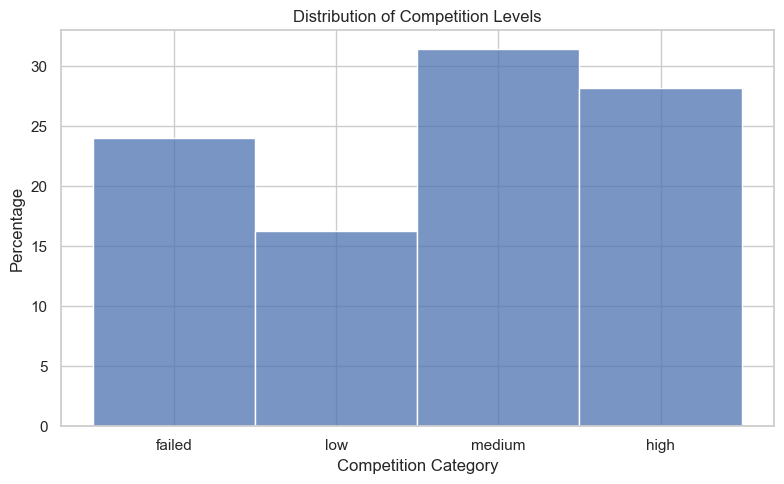

In [7]:
# distribution of competition levels          
plot_offers_bin_distribution(df, save=True)


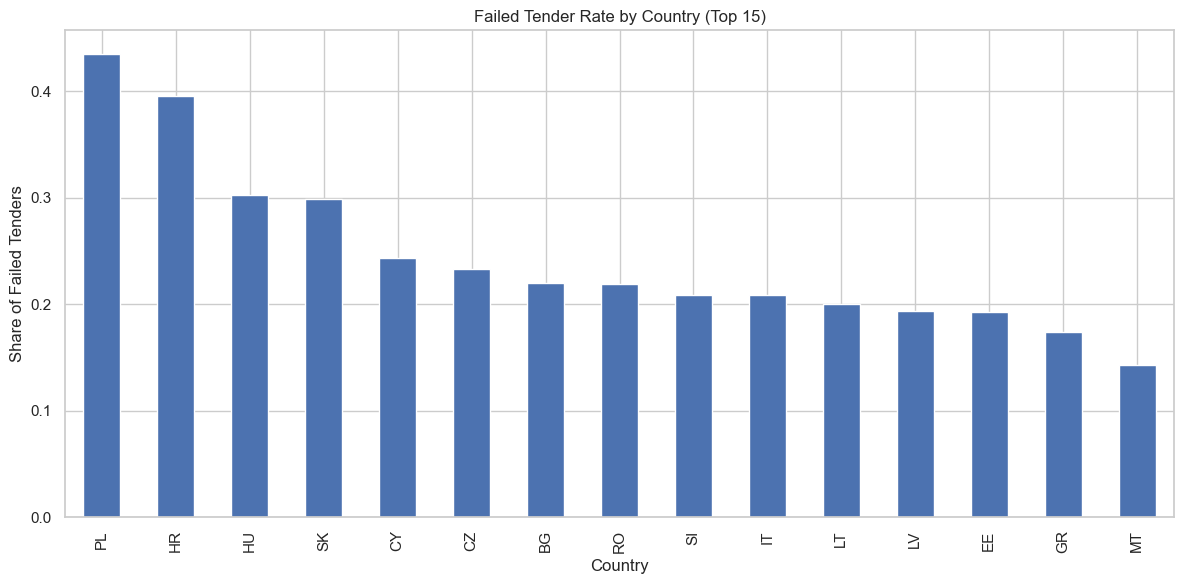

In [8]:
# competition by country

plot_failed_rate_by_country(df, save=True)

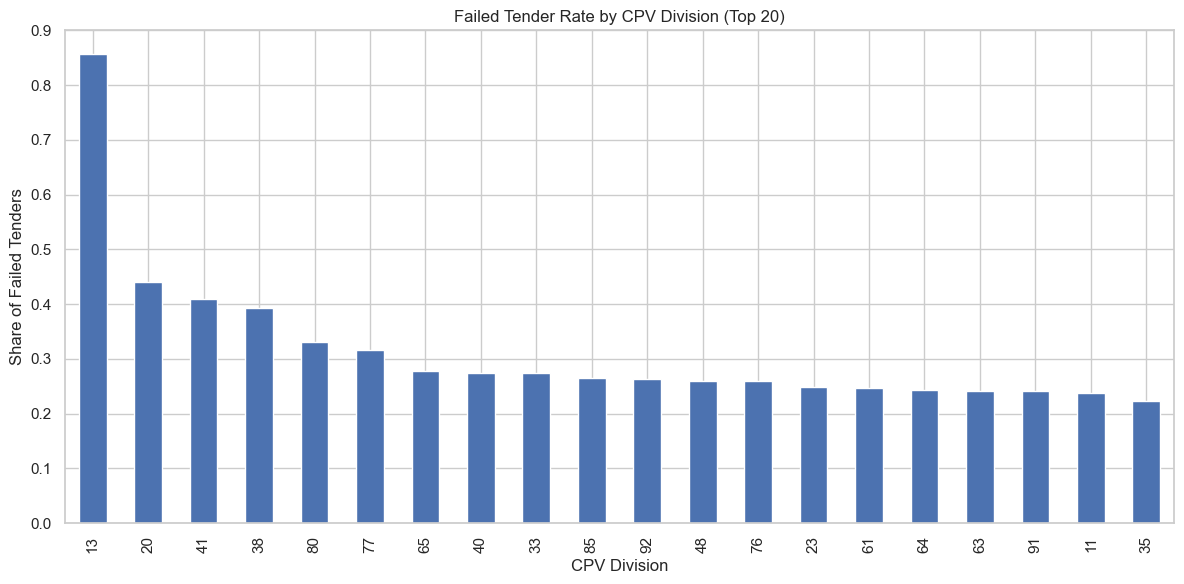

In [9]:
# competition by CPV division

plot_failed_rate_by_cpv_division(df, save=True)

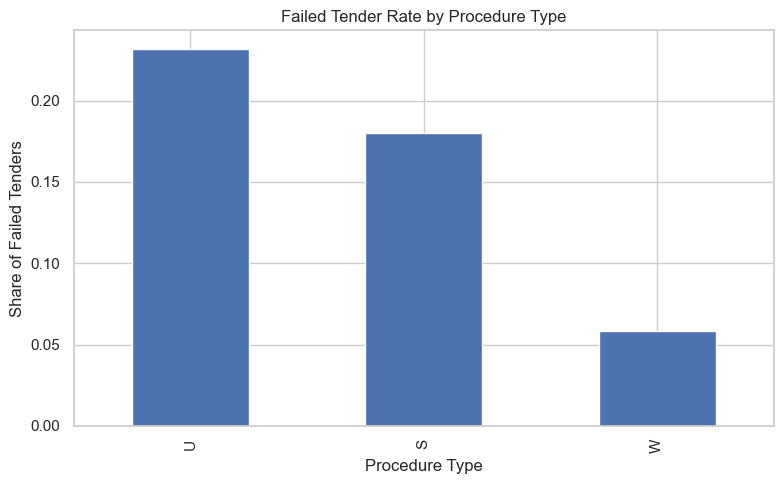

In [10]:
# competition by procedure type

plot_failed_rate_by_procedure(df, save=True)

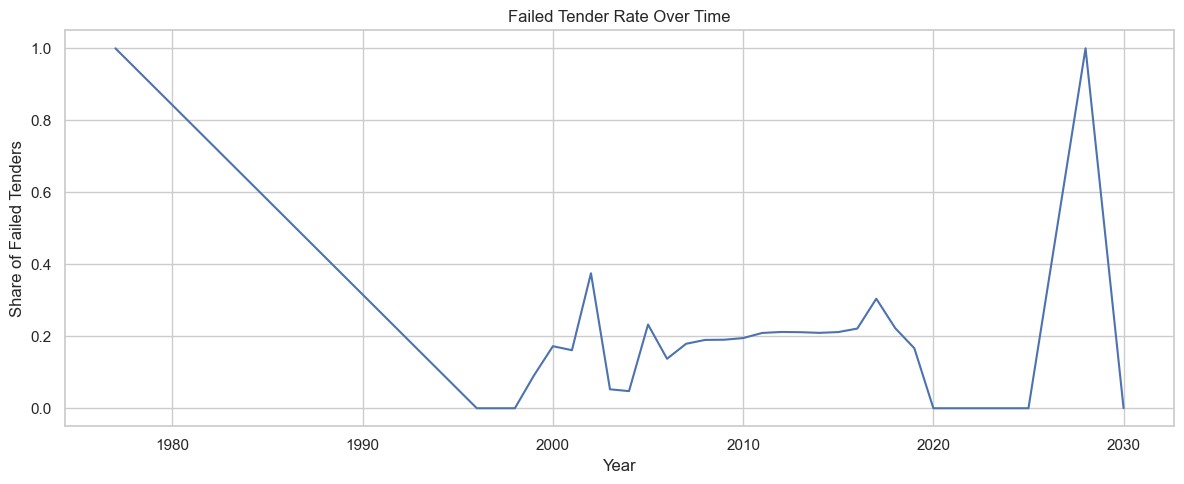

In [11]:
# competition over time

plot_failed_rate_over_time(df, save=True)

In [13]:
df['AWARD_YEAR'].value_counts().sort_index()


AWARD_YEAR
1,977.00         1
1,996.00         2
1,997.00         6
1,998.00         1
1,999.00        11
2,000.00        29
2,001.00        31
2,002.00        16
2,003.00        57
2,004.00        84
2,005.00       258
2,006.00      1084
2,007.00     61508
2,008.00    346171
2,009.00    375578
2,010.00    428327
2,011.00    465251
2,012.00    465105
2,013.00    482734
2,014.00    485429
2,015.00    512065
2,016.00    407349
2,017.00        23
2,018.00         9
2,019.00         6
2,020.00         5
2,021.00         5
2,022.00         1
2,025.00         1
2,028.00         1
2,030.00         1
Name: count, dtype: int64

In [15]:
df = df.drop(columns=["AWARD_YEAR", "AWARD_MONTH"])

#### Notes: Key Insights for Modelling Competition
1. Failed tenders are structurally uneven across countries
Some countries (PL, HR, HU, SK) consistently show very high failure rates.
Country is a strong predictor of competition outcomes.

2. CPV divisions differ dramatically in failure risk
Certain CPV sectors (e.g., division 13) have extremely high failure rates (up to ~90%).
Sector (CPV) is one of the strongest features for predicting competition.

3. Procedure type strongly affects failure probability
Procedure type U fails most often. S is moderate. W fails least.
Procedure type is a clear structural driver of competition.

4. Competition categories show a realistic distribution
Medium and high competition dominate. Failed competition is ~24–25%.
This confirms that the engineered feature OFFERS_BIN is meaningful and stable.

5. Why failed share dropped from 27.4% to ~25%
OFFERS_BIN has ~19% missing values. Failed tenders more often have missing NUMBER_OFFERS - they fall into NaN.
When plotting competition distribution, NaN rows are excluded.

6. Temporal features: YEAR is reliable, AWARD_YEAR is not
AWARD_YEAR and AWARD_MONTH were derived from corrupted raw dates (e.g., 1977, 2030).
YEAR (based on file year) is accurate and consistent.
We removed AWARD_YEAR and AWARD_MONTH because they distort temporal patterns and harm modelling.

7. Quarter is useful for modelling, month is not
MONTH adds unnecessary granularity and increases categorical complexity.

--------------
## Competition Analyse - Germany

--------------

In [ ]:
# competition overview

df_de[["IS_FAILED_TENDER", "IS_LOW_COMPETITION", "OFFERS_BIN"]].describe()

-------------------------

### SAVE DATASET

----------------------

In [ ]:
df.to_pickle("../data/dataset_final.pkl")
df_de.to_pickle("../data/dataset_de_final.pkl")